<a href="https://colab.research.google.com/github/firarru/TA/blob/main/Code_tanpa_standarisasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

#**Read Dataset**

In [2]:
url2020 = 'https://raw.githubusercontent.com/firarru/TA/refs/heads/main/Data/2020.csv'
url2021 = 'https://raw.githubusercontent.com/firarru/TA/refs/heads/main/Data/2021.csv'

df20 = pd.read_csv(url2020, sep=';')
df21 = pd.read_csv(url2021, sep=';')

/tmp/ipykernel_9327/3864618148.py:4: DtypeWarning: Columns (11,12,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df20 = pd.read_csv(url2020, sep=';')
/tmp/ipykernel_9327/3864618148.py:5: DtypeWarning: Columns (12,13,14,15,16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df21 = pd.read_csv(url2021, sep=';')


In [3]:
df20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61474 entries, 0 to 61473
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_STAMP   61474 non-null  object 
 1   ASSET_ID     61474 non-null  int64  
 2   PRESSURE     61474 non-null  object 
 3   TEMPERATURE  61474 non-null  object 
 4   ENERGY_RATE  61474 non-null  object 
 5   VOLUME_RATE  61474 non-null  object 
 6   C1           0 non-null      float64
 7   C2           61474 non-null  object 
 8   C3           61474 non-null  object 
 9   IC4          61474 non-null  object 
 10  NC4          61474 non-null  object 
 11  IC5          61474 non-null  object 
 12  NC5          61474 non-null  object 
 13  C6           61474 non-null  object 
 14  C7           61474 non-null  object 
 15  C8           61474 non-null  object 
 16  C9           61474 non-null  object 
 17  N2           61474 non-null  object 
 18  CO2          61474 non-null  object 
 19  H2O 

In [4]:
df21.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61313 entries, 0 to 61312
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_STAMP   61313 non-null  object 
 1   ASSET_ID     61313 non-null  int64  
 2   PRESSURE     61313 non-null  object 
 3   TEMPERATURE  61313 non-null  object 
 4   ENERGY_RATE  61313 non-null  object 
 5   VOLUME_RATE  61313 non-null  object 
 6   C1           0 non-null      float64
 7   C2           61313 non-null  object 
 8   C3           61313 non-null  object 
 9   IC4          61313 non-null  object 
 10  NC4          61313 non-null  object 
 11  IC5          61313 non-null  object 
 12  NC5          61313 non-null  object 
 13  C6           61313 non-null  object 
 14  C7           61313 non-null  object 
 15  C8           61313 non-null  object 
 16  C9           61313 non-null  object 
 17  N2           61313 non-null  object 
 18  CO2          61313 non-null  object 
 19  H2O 

# **Preprocessing**

Menggabungkan Data

In [5]:
df20['DATE_STAMP'] = pd.to_datetime(df20['DATE_STAMP'], errors='coerce')
df21['DATE_STAMP'] = pd.to_datetime(df21['DATE_STAMP'], errors='coerce')

In [6]:
df = pd.concat([df20, df21], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122787 entries, 0 to 122786
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   DATE_STAMP   122787 non-null  datetime64[ns]
 1   ASSET_ID     122787 non-null  int64         
 2   PRESSURE     122787 non-null  object        
 3   TEMPERATURE  122787 non-null  object        
 4   ENERGY_RATE  122787 non-null  object        
 5   VOLUME_RATE  122787 non-null  object        
 6   C1           0 non-null       float64       
 7   C2           122787 non-null  object        
 8   C3           122787 non-null  object        
 9   IC4          122787 non-null  object        
 10  NC4          122787 non-null  object        
 11  IC5          122787 non-null  object        
 12  NC5          122787 non-null  object        
 13  C6           122787 non-null  object        
 14  C7           122787 non-null  object        
 15  C8           122787 non-null  obje

Filter Periode Data

In [7]:
df['DATE_STAMP'] = pd.to_datetime(df['DATE_STAMP'])

df_filter = df.loc[
    (df['DATE_STAMP'] >= '2020-06-01 00:00:00') &
    (df['DATE_STAMP'] <= '2021-06-30 23:00:00')
].reset_index(drop=True)

Filter Feature

In [8]:
df = df_filter[['DATE_STAMP', 'ASSET_ID', 'PRESSURE']]
df

,DATE_STAMP,ASSET_ID,PRESSURE
0,2020-06-01 00:00:00,133071,58.910.308.837.890.600
1,2020-06-01 00:00:00,133004,15.661.116.943.359.300
2,2020-06-01 00:00:00,133002,15.512.724.609.375
3,2020-06-01 00:00:00,133003,1.500.152.587.890.620
4,2020-06-01 00:00:00,133060,12.791.077.880.859.300
...,...,...,...
66341,2021-06-30 23:00:00,133004,14.935.035.400.390.600
66342,2021-06-30 23:00:00,133070,57.954.241.943.359.300
66343,2021-06-30 23:00:00,133003,14.158.846.435.546.800
66344,2021-06-30 23:00:00,133071,5.889.481.201.171.870


Transformasi

In [9]:
df['PRESSURE'] = (df['PRESSURE'].astype(str).str.replace(".", "", regex=False).astype(float))

/tmp/ipykernel_9327/898852785.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PRESSURE'] = (df['PRESSURE'].astype(str).str.replace(".", "", regex=False).astype(float))


In [10]:
asset_name_mapping = {
    133001: 'Anoa',
    133002: 'Kakap',
    133003: 'Hang Tuah',
    133004: 'Gajah Baru',
    133060: 'ORF'
}

df['ASSET_ID'] = df['ASSET_ID'].replace(asset_name_mapping)

df = df[df['ASSET_ID'].isin(asset_name_mapping.values())]

/tmp/ipykernel_9327/3313337121.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ASSET_ID'] = df['ASSET_ID'].replace(asset_name_mapping)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47390 entries, 1 to 66345
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DATE_STAMP  47390 non-null  datetime64[ns]
 1   ASSET_ID    47390 non-null  object        
 2   PRESSURE    47390 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.4+ MB


In [12]:
df

,DATE_STAMP,ASSET_ID,PRESSURE
1,2020-06-01 00:00:00,Gajah Baru,1.566112e+16
2,2020-06-01 00:00:00,Kakap,1.551272e+13
3,2020-06-01 00:00:00,Hang Tuah,1.500153e+15
4,2020-06-01 00:00:00,ORF,1.279108e+16
5,2020-06-01 00:00:00,Anoa,1.555127e+12
...,...,...,...
66339,2021-06-30 23:00:00,ORF,1.218315e+15
66340,2021-06-30 23:00:00,Anoa,1.478760e+12
66341,2021-06-30 23:00:00,Gajah Baru,1.493504e+16
66343,2021-06-30 23:00:00,Hang Tuah,1.415885e+16


In [13]:
df['ASSET_ID'].groupby(df['ASSET_ID']).count()

,ASSET_ID
ASSET_ID,
Anoa,9478
Gajah Baru,9478
Hang Tuah,9478
Kakap,9478
ORF,9478


In [14]:
df.head(10)

,DATE_STAMP,ASSET_ID,PRESSURE
1,2020-06-01 00:00:00,Gajah Baru,1.566112e+16
2,2020-06-01 00:00:00,Kakap,1.551272e+13
3,2020-06-01 00:00:00,Hang Tuah,1.500153e+15
4,2020-06-01 00:00:00,ORF,1.279108e+16
5,2020-06-01 00:00:00,Anoa,1.555127e+12
8,2020-06-01 01:00:00,Gajah Baru,1.563403e+13
9,2020-06-01 01:00:00,Anoa,1.552637e+11
10,2020-06-01 01:00:00,Kakap,1.549067e+15
12,2020-06-01 01:00:00,Hang Tuah,1.498398e+16
13,2020-06-01 01:00:00,ORF,1.282924e+16


## Visualisasi Graf

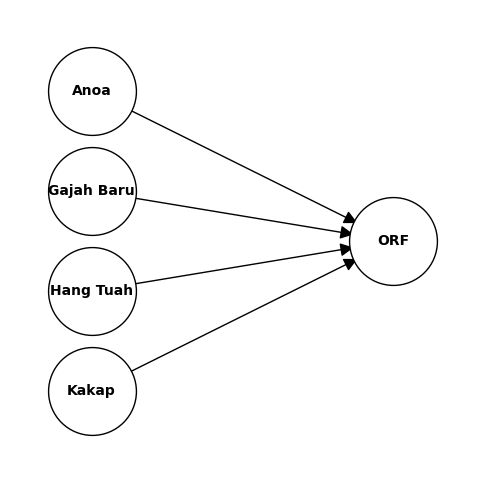

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

#Inisialisasi Graf Berarah
G = nx.DiGraph()

sources = ["Anoa", "Gajah Baru", "Hang Tuah", "Kakap"]
sink = "ORF"

#Menambah Edge
for s in sources:
    G.add_edge(s, sink)

#Posisi Node
pos = {
    "Anoa": (-1, 3),
    "Gajah Baru": (-1, 1),
    "Hang Tuah": (-1, -1),
    "Kakap": (-1, -3),
    "ORF": (1, 0)
}

#Visualisasi
plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, nodelist=sources, node_color='white', node_size=4000, edgecolors='black')
nx.draw_networkx_nodes(G, pos, nodelist=[sink], node_color='white', node_size=4000, edgecolors='black')

#Gambar Edge dan Label
nx.draw_networkx_edges(G, pos, edge_color='black', arrows=True, arrowstyle='-|>', arrowsize=20, min_source_margin=10, min_target_margin=29)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.axis('off')
plt.margins(0.2)
plt.show()

##**Menghitung Bobot Edge**

In [16]:
#Memisahkan source dg sink
df_orf = df[df['ASSET_ID'] == 'ORF']
df_orf = df_orf.rename(columns={
    'PRESSURE': 'PRESSURE_ORF',
    'ASSET_ID': 'ID_ORF'})
df_orf.shape

(9478, 3)

In [17]:
df_fix = pd.merge(df, df_orf, on='DATE_STAMP')
df_fix = df_fix.drop(columns=['ID_ORF'])
df_fix = df_fix[df_fix['ASSET_ID'] != 'ORF'].reset_index(drop=True)

In [18]:
df_fix.head()

,DATE_STAMP,ASSET_ID,PRESSURE,PRESSURE_ORF
0,2020-06-01 00:00:00,Gajah Baru,1.566112e+16,1.279108e+16
1,2020-06-01 00:00:00,Kakap,1.551272e+13,1.279108e+16
2,2020-06-01 00:00:00,Hang Tuah,1.500153e+15,1.279108e+16
3,2020-06-01 00:00:00,Anoa,1.555127e+12,1.279108e+16
4,2020-06-01 01:00:00,Gajah Baru,1.563403e+13,1.282924e+16


In [19]:
#menghitung selisih bobot sink - source berdasarkan waktu t
df_fix['WEIGHT'] = (df_fix['PRESSURE_ORF'] - df_fix['PRESSURE']).abs()

In [20]:
df_fix

,DATE_STAMP,ASSET_ID,PRESSURE,PRESSURE_ORF,WEIGHT
0,2020-06-01 00:00:00,Gajah Baru,1.566112e+16,1.279108e+16,2.870039e+15
1,2020-06-01 00:00:00,Kakap,1.551272e+13,1.279108e+16,1.277557e+16
2,2020-06-01 00:00:00,Hang Tuah,1.500153e+15,1.279108e+16,1.129093e+16
3,2020-06-01 00:00:00,Anoa,1.555127e+12,1.279108e+16,1.278952e+16
4,2020-06-01 01:00:00,Gajah Baru,1.563403e+13,1.282924e+16,1.281361e+16
...,...,...,...,...,...
37907,2021-06-30 22:00:00,Kakap,1.481314e+15,1.217497e+16,1.069366e+16
37908,2021-06-30 23:00:00,Anoa,1.478760e+12,1.218315e+15,1.216836e+15
37909,2021-06-30 23:00:00,Gajah Baru,1.493504e+16,1.218315e+15,1.371672e+16
37910,2021-06-30 23:00:00,Hang Tuah,1.415885e+16,1.218315e+15,1.294053e+16


**Visualisasi Graph**

In [21]:
# import networkx as nx
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# #mengambil waktu unik pada 1 minggu pertama
# times = df_fix['DATE_STAMP'].unique()[:24]

# #definisi posisi node agar konsisten untuk setiap gambar
# pos = {
#     "Anoa": (-1, 3),
#     "Gajah Baru": (-1, 1),
#     "Hang Tuah": (-1, -1),
#     "Kakap": (-1, -3),
#     "ORF": (1, 0)
# }

# fig, ax = plt.subplots(figsize=(6, 5))

# def update(frame):
#   ax.clear()

#   #filter data dari setiap timestamp pada frame ke-i
#   df_t = df_fix[df_fix['DATE_STAMP'] == times[frame]]

#   #membuat graph berarah
#   G = nx.DiGraph()

#   #menambahkan edge
#   for _, row in df_t.iterrows():
#     source = row['ASSET_ID']
#     weight = row['WEIGHT']
#     G.add_edge(source, 'ORF', weight=weight)

#   weights = [abs(G[u][v]['weight']) for u, v in G.edges()]

#   #menampilkan graph
#   nx.draw(
#       G,
#       pos,
#       ax=ax,
#       with_labels=True,
#       node_size=2500,
#       arrows=True,
#       width=weights
#   )

#   #memampilkan label bobot
#   edge_labels = nx.get_edge_attributes(G, 'weight')
#   nx.draw_networkx_edge_labels(pos=pos, G=G, edge_labels=edge_labels, ax=ax)

#   ax.set_title(f'Time: {times[frame]}')
#   ax.axis('off')

# #membuat animasi
# ani = FuncAnimation(fig, update, frames=len(times), interval=200)

# HTML(ani.to_jshtml())


**Penerapan Sliding Window**

In [22]:
#definisi ukuran window
w = 24 #untuk 24 jam

features_list = []

#penerapan sliding window pada setiap asset
for asset in df_fix['ASSET_ID'].unique():

  #mengambil deret waktu bobot untuk asset tsb
  df_asset = df_fix[df_fix['ASSET_ID'] == asset].reset_index(drop=True)

  weights = df_asset['WEIGHT'].values
  times = df_asset['DATE_STAMP'].values

  N = len(weights)

  for t in range(w,N):
    #slice window
    window = weights[t-w:t]

    #statistik agregat
    mean = window.mean()
    std = window.std()

    #menyimpan fitur ke dalam bentuk vektor
    features_list.append({
        "frame": t-w+1,
        "DATE_STAMP": times[t],
        "EDGE": f"{asset}->ORF:",
        "MEAN_WEIGHT": mean,
        "STD_WEIGHT": std
    })

#matriks fitur
X_feature = pd.DataFrame(features_list)

X_feature


,frame,DATE_STAMP,EDGE,MEAN_WEIGHT,STD_WEIGHT
0,1,2020-06-02 00:00:00,Gajah Baru->ORF:,7.182506e+15,6.163118e+15
1,2,2020-06-02 01:00:00,Gajah Baru->ORF:,7.123220e+15,6.210974e+15
2,3,2020-06-02 02:00:00,Gajah Baru->ORF:,6.649524e+15,6.192422e+15
3,4,2020-06-02 03:00:00,Gajah Baru->ORF:,6.585008e+15,6.252999e+15
4,5,2020-06-02 04:00:00,Gajah Baru->ORF:,6.534305e+15,6.289438e+15
...,...,...,...,...,...
37811,9450,2021-06-30 19:00:00,Anoa->ORF:,4.876986e+15,5.550684e+15
37812,9451,2021-06-30 20:00:00,Anoa->ORF:,4.833080e+15,5.583867e+15
37813,9452,2021-06-30 21:00:00,Anoa->ORF:,4.393913e+15,5.434348e+15
37814,9453,2021-06-30 22:00:00,Anoa->ORF:,4.393917e+15,5.434345e+15


# **IF**

In [23]:
import numpy as np

mendefinisikan pohon isolasi untuk menghitung path length



In [24]:
class IsolationTreeNode:
  def __init__(self, feature=None, split=None, left=None, right=None, size=None):
    self.feature = feature
    self.split = split
    self.left = left
    self.right = right
    self.size = size

membangun pohon isolasi dan rekursif pohon isolasi

In [25]:
def build_tree(X, height, max_height):
  if height >= max_height or len(X) <= 1:
    return IsolationTreeNode(size=len(X))

  #pilih fitur acak
  n_features = X.shape[1]

  q = np.random.randint(n_features)

  #menentukan nilai split/pemisah dari min dan max
  min_val = X[:,q].min()
  max_val = X[:,q].max()

  if min_val == max_val:
    return IsolationTreeNode(size=len(X))

  #pisah nilai pemisah secara acak
  p = np.random.uniform(min_val, max_val)

  #membagi data menjadi kiri dan kanan (2)
  X_left = X[X[:,q] < p]
  X_right = X[X[:,q] >= p]

  left = build_tree(X_left, height+1, max_height)
  right = build_tree(X_right, height+1, max_height)

  #menyimpan fitur split, nilai split, dan child node
  return IsolationTreeNode(q, p, left, right)

menghitung path length (height)

In [26]:
def path_length(x, node, height):

    if node.size is not None:
        return height

    if x[node.feature] < node.split:
        return path_length(x, node.left, height+1)
    else:
        return path_length(x, node.right, height+1)

normalisasi

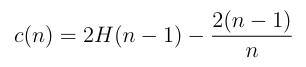

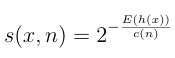

In [27]:
def c_factor(n):

    if n <= 1:
        return 0

    H = np.log(n-1) + 0.5772156649
    return 2*H - (2*(n-1)/n)

membangun model

In [28]:
class IsolationForest:

    #set parameter
    def __init__(self, n_trees=100, sample_size=256):
        self.n_trees = n_trees
        self.sample_size = sample_size
        self.trees = []

    #rekursif pohon isolasi
    def fit(self, X):

        self.trees = []

        max_height = int(np.ceil(np.log2(self.sample_size)))

        for i in range(self.n_trees):

            #ambil sampel acak
            idx = np.random.choice(len(X), self.sample_size, replace=False)
            X_sub = X[idx]

            tree = build_tree(X_sub, 0, max_height)
            self.trees.append(tree)

    #menghitung skor anomali
    def anomaly_score(self, X):

        scores = []

        for x in X:

            path_lengths = []

            for tree in self.trees:
                path_lengths.append(path_length(x, tree, 0))

            Ehx = np.mean(path_lengths)
            cn = c_factor(self.sample_size)

            score = 2 ** (-Ehx / cn)
            scores.append(score)

        return np.array(scores)

Train

In [33]:
X = X_feature[['MEAN_WEIGHT', 'STD_WEIGHT']].values

model = IsolationForest(
    n_trees=100,
    sample_size=256
)

model.fit(X)
scores = model.anomaly_score(X)

In [ ]:
labels

In [34]:
scores

array([0.58319172, 0.58437666, 0.58477218, ..., 0.58516796, 0.58516796,
       0.5824031 ])

In [42]:
X_feature['anomaly_score'] = scores
# X_feature['label'] = labels

X_feature

,frame,DATE_STAMP,EDGE,MEAN_WEIGHT,STD_WEIGHT,anomaly_score
0,1,2020-06-02 00:00:00,Gajah Baru->ORF:,7.182506e+15,6.163118e+15,0.005059
1,2,2020-06-02 01:00:00,Gajah Baru->ORF:,7.123220e+15,6.210974e+15,0.010129
2,3,2020-06-02 02:00:00,Gajah Baru->ORF:,6.649524e+15,6.192422e+15,0.011821
3,4,2020-06-02 03:00:00,Gajah Baru->ORF:,6.585008e+15,6.252999e+15,0.016904
4,5,2020-06-02 04:00:00,Gajah Baru->ORF:,6.534305e+15,6.289438e+15,0.016904
...,...,...,...,...,...,...
37811,9450,2021-06-30 19:00:00,Anoa->ORF:,4.876986e+15,5.550684e+15,0.005059
37812,9451,2021-06-30 20:00:00,Anoa->ORF:,4.833080e+15,5.583867e+15,0.001685
37813,9452,2021-06-30 21:00:00,Anoa->ORF:,4.393913e+15,5.434348e+15,0.013514
37814,9453,2021-06-30 22:00:00,Anoa->ORF:,4.393917e+15,5.434345e+15,0.013514


In [43]:
X_feature['anomaly_score'].describe()

,anomaly_score
count,37816.000000
mean,0.048330
std,0.133360
min,0.000000
25%,0.001685
50%,0.008438
75%,0.021998
max,1.000000


In [41]:
def predict_threshold(scores, threshold):
  labels = (scores > threshold).astype(int)
  return labels

# def normalize_scores(scores):
#   return (scores - scores.min()) / (scores.max() - scores.min())

# scores = normalize_scores(scores)

thresholds = [0.5]

for t in thresholds:
    labels_t = predict_threshold(scores, t)
    print(f"Threshold {t}: {labels_t.sum()} anomali")

Threshold 0.5: 1126 anomali


/tmp/ipykernel_9327/1550056729.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


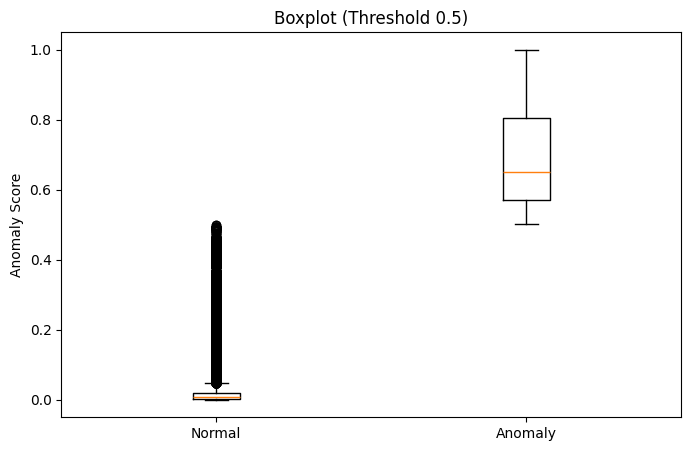

In [39]:
plt.figure(figsize=(8,5))

plt.boxplot([
    scores[labels_t == 0],
    scores[labels_t == 1]
], labels=['Normal', 'Anomaly'])

plt.title("Boxplot (Threshold 0.5)")
plt.ylabel("Anomaly Score")
plt.show()